**Exploitation des donnée**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
data= pd.read_csv('../data/dataset.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [3]:
data.describe()


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [4]:
data.isnull().sum()


Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

**Preparation data**

**transform nulls in numeric variables to mean of the feature**

**transform nulls in categorial variables to the most repeated one or each feature** 

In [5]:

data_columns= data.columns
for i in data_columns:
    if data[i].dtype == 'int64' or data[i].dtype == 'float64':
         data[i]=  data[i].fillna(data[i].mean())
    if data[i].dtype == 'object':
        data[i] = data[i].fillna(data[i].mode()[0])
prepared_data = data.copy()
prepared_data.isnull().sum()


Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [ ]:
data.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


**Corrélation des variables numériques**

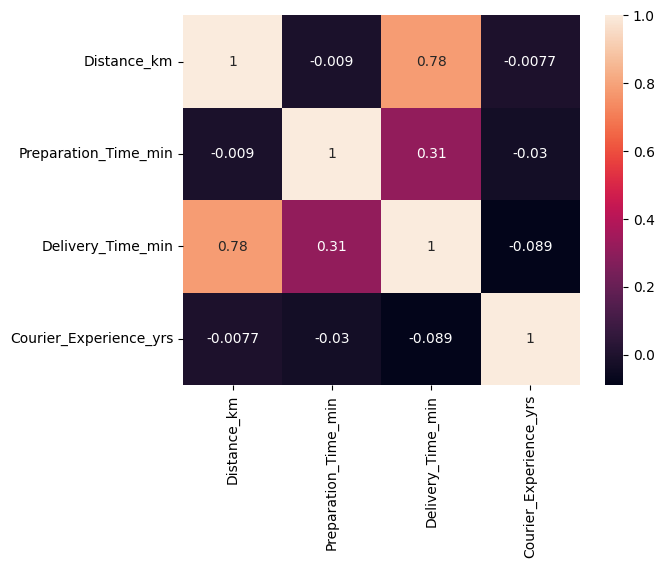

In [7]:
numerical_features =  prepared_data[['Distance_km', 'Preparation_Time_min', 'Delivery_Time_min', 'Courier_Experience_yrs']].copy()
numerical_features.head()
correlation_distance= numerical_features.corr(numeric_only=True)
sns= sns.heatmap(correlation_distance, annot=True)


*Remarque : En remarque que Delivery_time_min a une forte corelation avec Distance_km alors que Preparation_Time_min et Courier_Experience_yrs a une correlation inverse faible avec Distance_km*

**Analyser les variables categorial**

In [8]:
prepared_data.head(10)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,Morning,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


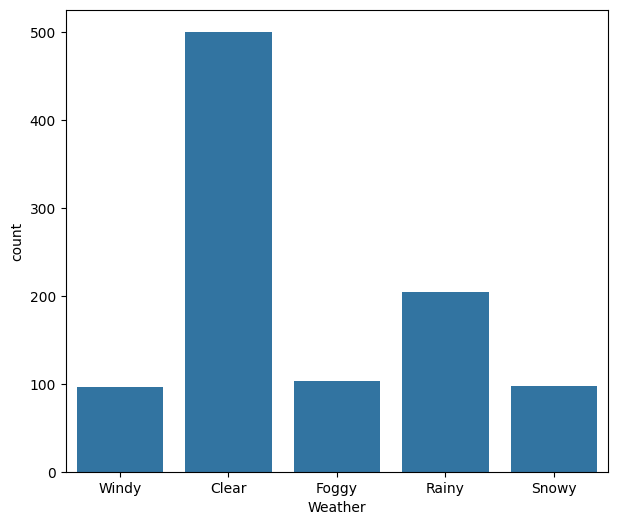

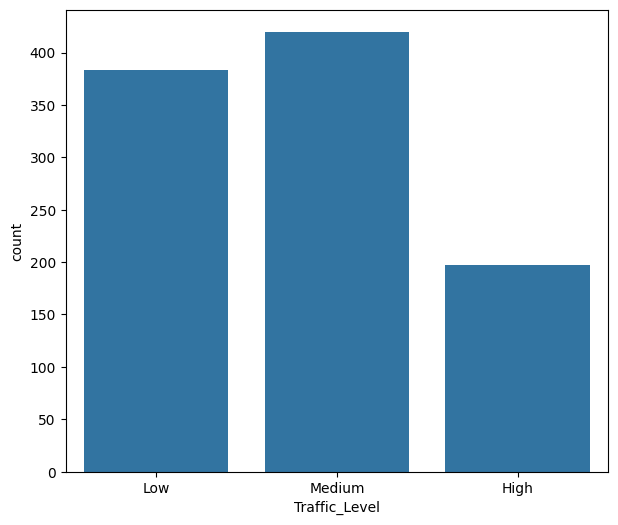

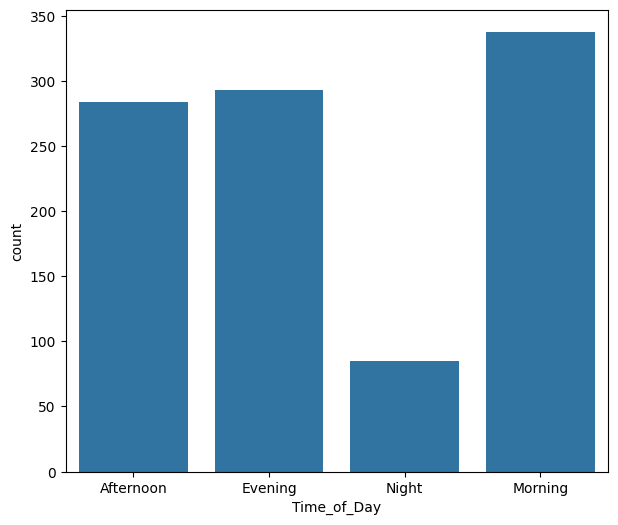

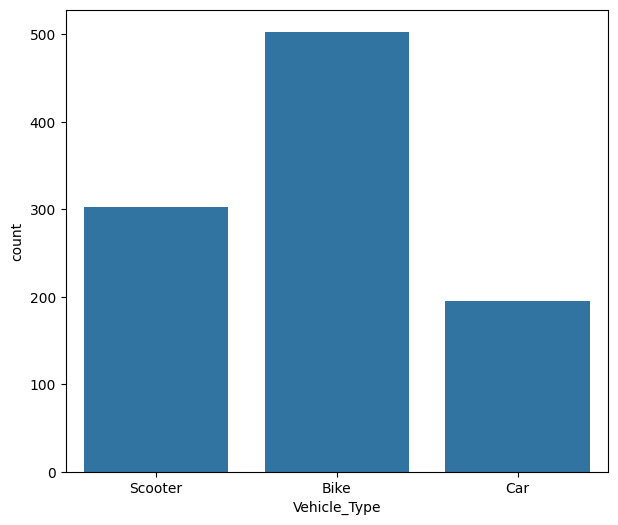

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
prepared_data.head(10)

categorial_columns= ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in categorial_columns:
        plt.figure(figsize=(7,6))
        data_countplot= prepared_data.groupby(col).size()
        # print("eddz", data_countplot)
        sns.countplot(data=prepared_data, x=col)
        # plt.show()

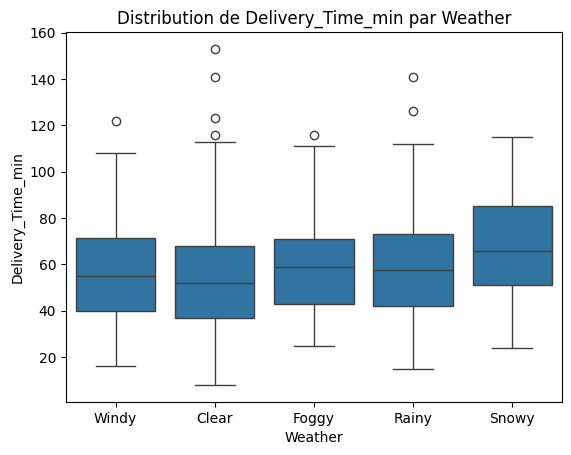

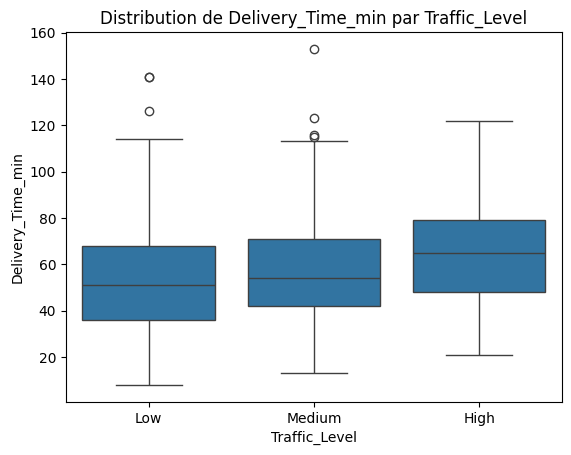

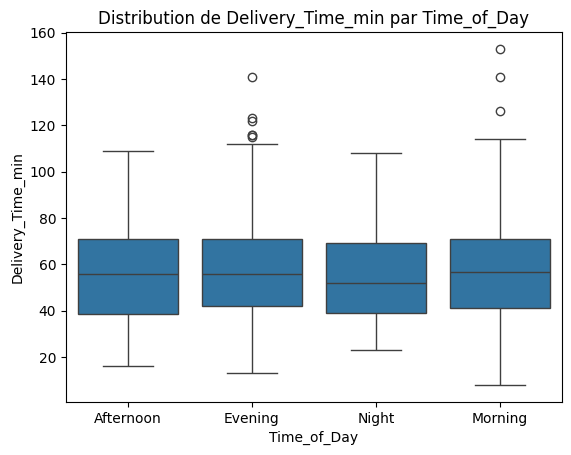

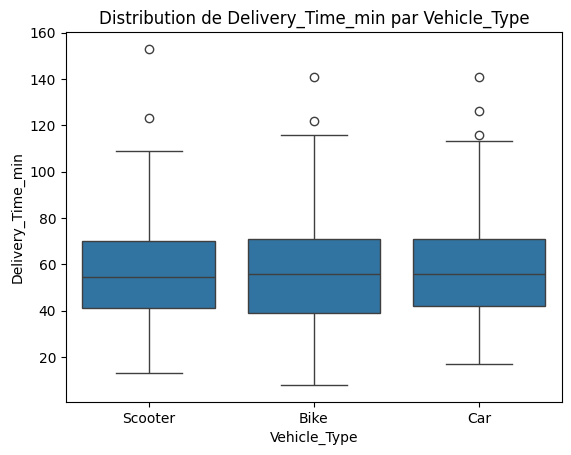

In [10]:
categorial_columns= ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
# prepared_data['Delivery_Time_min'] = pd.qcut(prepared_data['Delivery_Time_min'], q=4, labels=False, duplicates='drop' )
for col in categorial_columns:
    sns.boxplot(data=prepared_data, x=col, y='Delivery_Time_min')
    plt.title(f'Distribution de Delivery_Time_min par {col}')
    plt.show()

**distribution de la variabl cible**

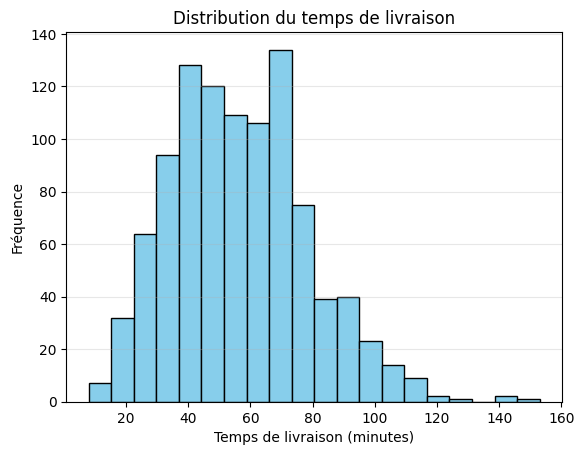

In [13]:
plt.hist(data['Delivery_Time_min'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution du temps de livraison')
plt.xlabel('Temps de livraison (minutes)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [12]:
import sys
sys.path.append('C:\Users\hp\Documents\projects\simplon_projects\prediction_du_Temps_de_Livraison')

from functions.fonctions import select_k_best, prepare_data, encode_data, split_data
prepared_data= prepare_data(data)
splited_data=split_data(prepared_data)
print(select_k_best(prepared_data))

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1981815066.py, line 2)